In [ ]:
!gdown --id 1xC9jjzvkRQ0vujN3LTQ7wGEqT9V5QBih
!unzip "World Happiness Report 2024.zip" -d WorldHappinessReport2024

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xC9jjzvkRQ0vujN3LTQ7wGEqT9V5QBih
To: /content/World Happiness Report 2024.zip
100% 185k/185k [00:00<00:00, 4.78MB/s]
Archive:  World Happiness Report 2024.zip
  inflating: WorldHappinessReport2024/World Happiness Report 2024.csv  


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# EDA

In [ ]:
df = pd.read_csv("WorldHappinessReport2024/World Happiness Report 2024.csv")
df.tail()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
2358,Zimbabwe,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.050874,0.830652,0.658434,0.235354
2359,Zimbabwe,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.002848,0.788523,0.660658,0.345736
2360,Zimbabwe,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.079007,0.756945,0.609917,0.241682
2361,Zimbabwe,2022,3.296220,7.670073,0.666172,54.525002,0.651987,-0.072935,0.752632,0.640609,0.191350
2362,Zimbabwe,2023,3.572386,7.678590,0.693817,55.000000,0.734613,-0.068837,0.757494,0.609752,0.178953


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   object 
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 203.2+ KB


In [ ]:
df.columns

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect'],
      dtype='object')

In [ ]:
cate_cols =['Country name']
num_cols = ['year', 'Log GDP per capita',
            'Social support', 'Healthy life expectancy at birth',
            'Freedom to make life choices', 'Generosity',
            'Perceptions of corruption', 'Positive affect', 'Negative affect']
target_col = ['Life Ladder']

In [ ]:
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print(len(df[col].unique()))
    print("------")

Unique values in Country name:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo (Brazzaville)' 'Congo (Kinshasa)'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Eswatini'
 'Ethiopia' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guyana' 'Haiti' 'Honduras'
 'Hong Kong S.A.R. of China' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Ivory Coast' 'Jamaica' 'Japan'
 'Jordan' 'Kazakhstan' 'Kenya' 'Kosovo' 'Kuwait' 'Kyrgyzstan' 'Laos'
 'Latvia' 'Lebanon' 'Lesotho' 'Liberia' 'Libya' 'Lithuania' 'Luxemb

/tmp/ipython-input-2558077737.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


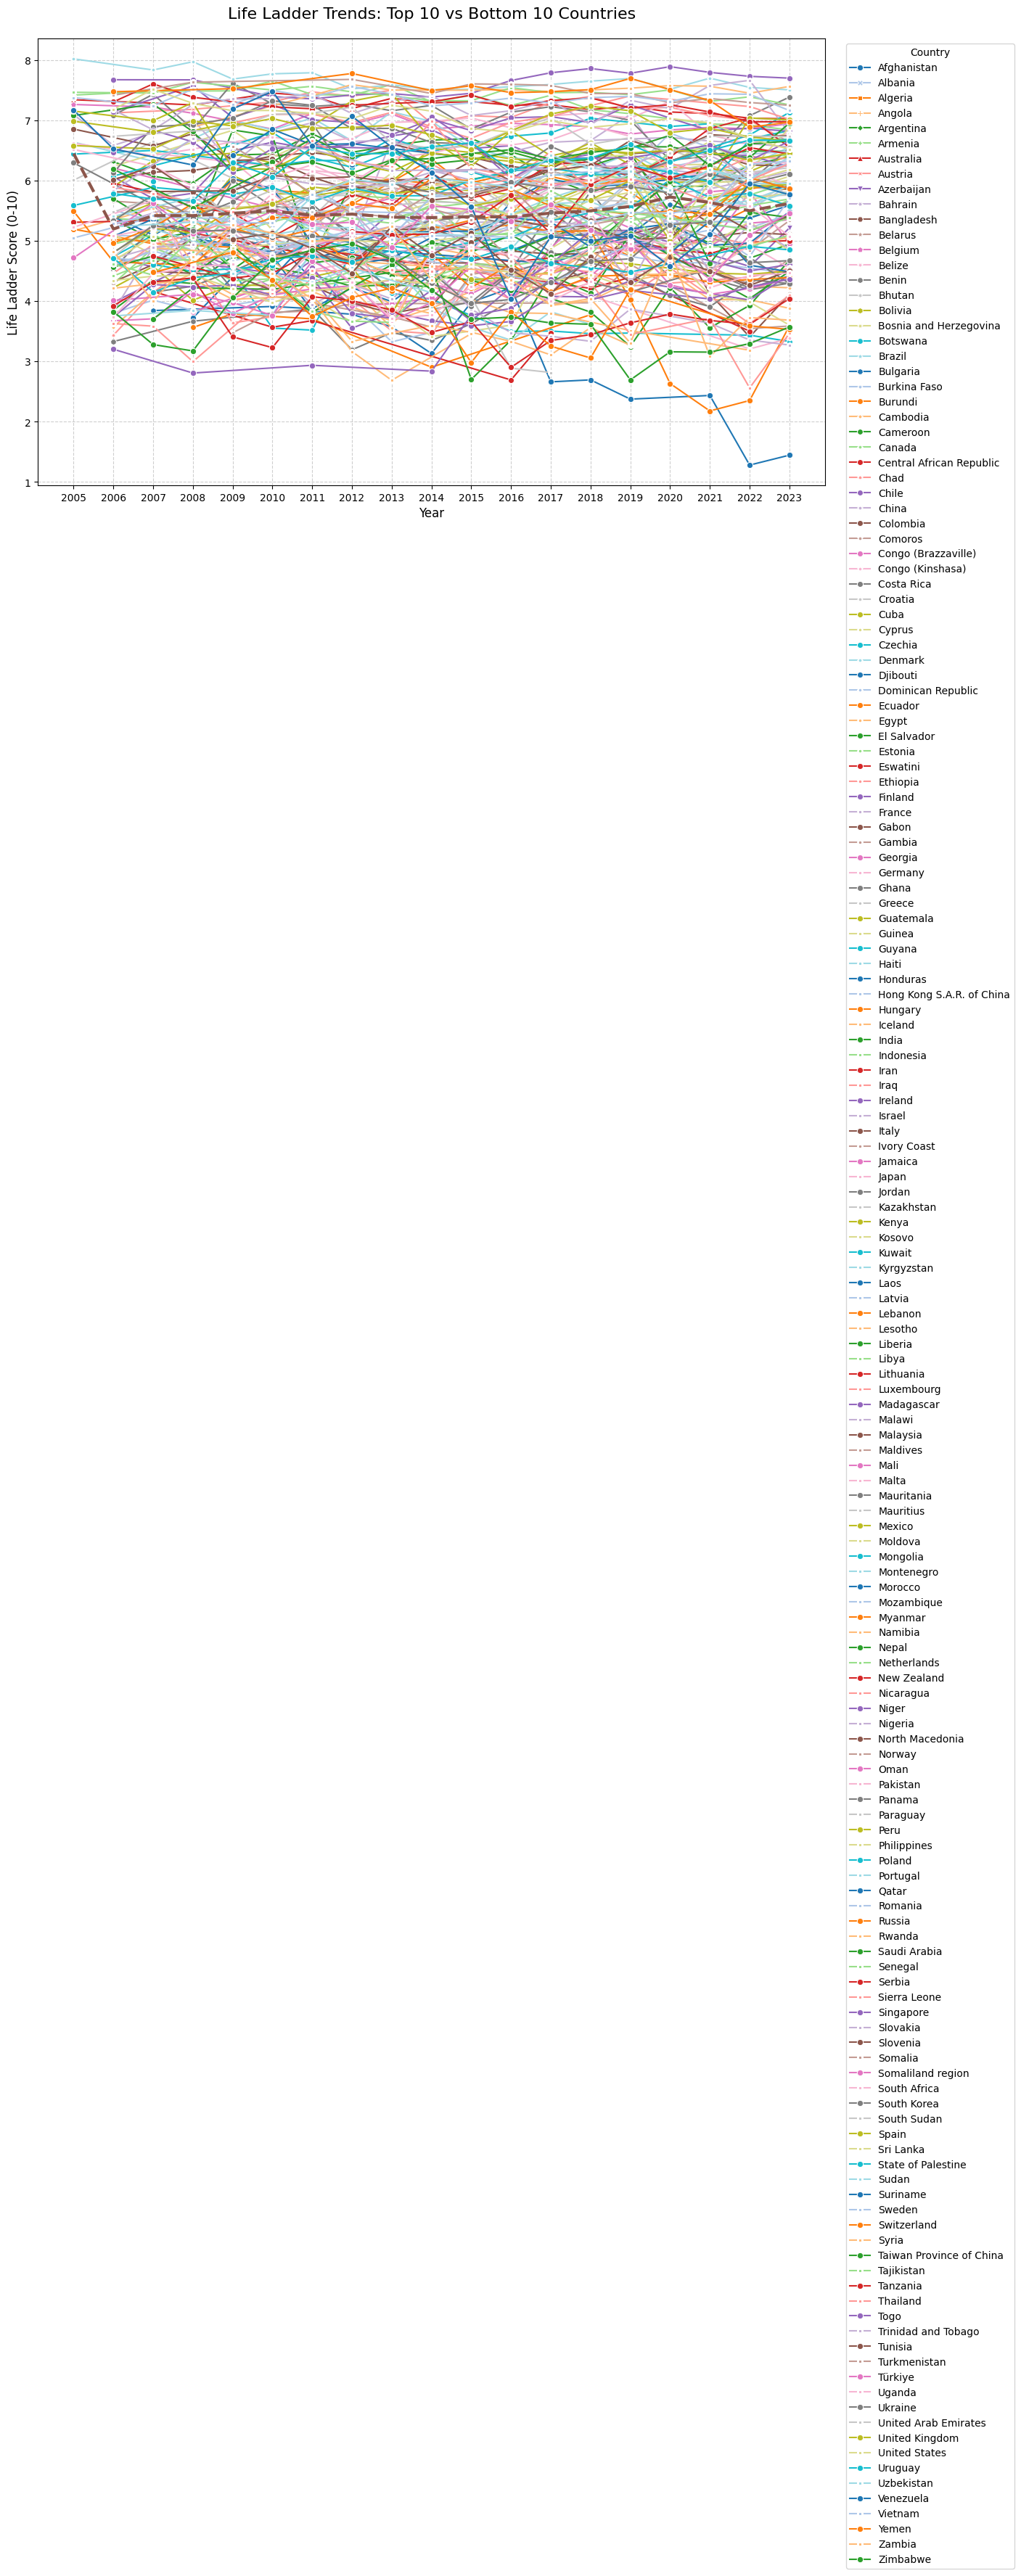

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the columns are named correctly as per your data
# Expected: 'Country name', 'year', 'Life Ladder'

# 2. Select countries to plot to avoid overcrowding
# We will pick the Top 10 and Bottom 10 countries by average Life Ladder score
avg_happiness = df.groupby('Country name')['Life Ladder'].mean().sort_values(ascending=False)

top_10_countries = avg_happiness.head(85).index.tolist()
bottom_10_countries = avg_happiness.tail(80).index.tolist()
selected_countries = top_10_countries + bottom_10_countries

# Filter the dataframe
plot_data = df[df['Country name'].isin(selected_countries)]

# 3. Create the Time Series Plot
plt.figure(figsize=(14, 8))

# Use seaborn for easier handling of groups (hue)
sns.lineplot(
    data=plot_data,
    x='year',
    y='Life Ladder',
    hue='Country name',
    style='Country name', # Adds different line styles for better distinction
    markers=True,
    dashes=False,
    palette='tab20'       # A palette with many distinct colors
)

# Customizing the plot
plt.title('Life Ladder Trends: Top 10 vs Bottom 10 Countries', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Ladder Score (0-10)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df['year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()

# Add mean Life Ladder line
# Compute mean Life Ladder per year
mean_per_year = (
    plot_data
    .groupby('year')['Life Ladder']
    .mean()
    .reset_index()
)

# Plot mean per year line
plt.plot(
    mean_per_year['year'],
    mean_per_year['Life Ladder'],
    linestyle='--',
    linewidth=3,
    label='Mean Life Ladder per Year'
)

# 4. Show the plot
plt.show()

/tmp/ipython-input-2917265785.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


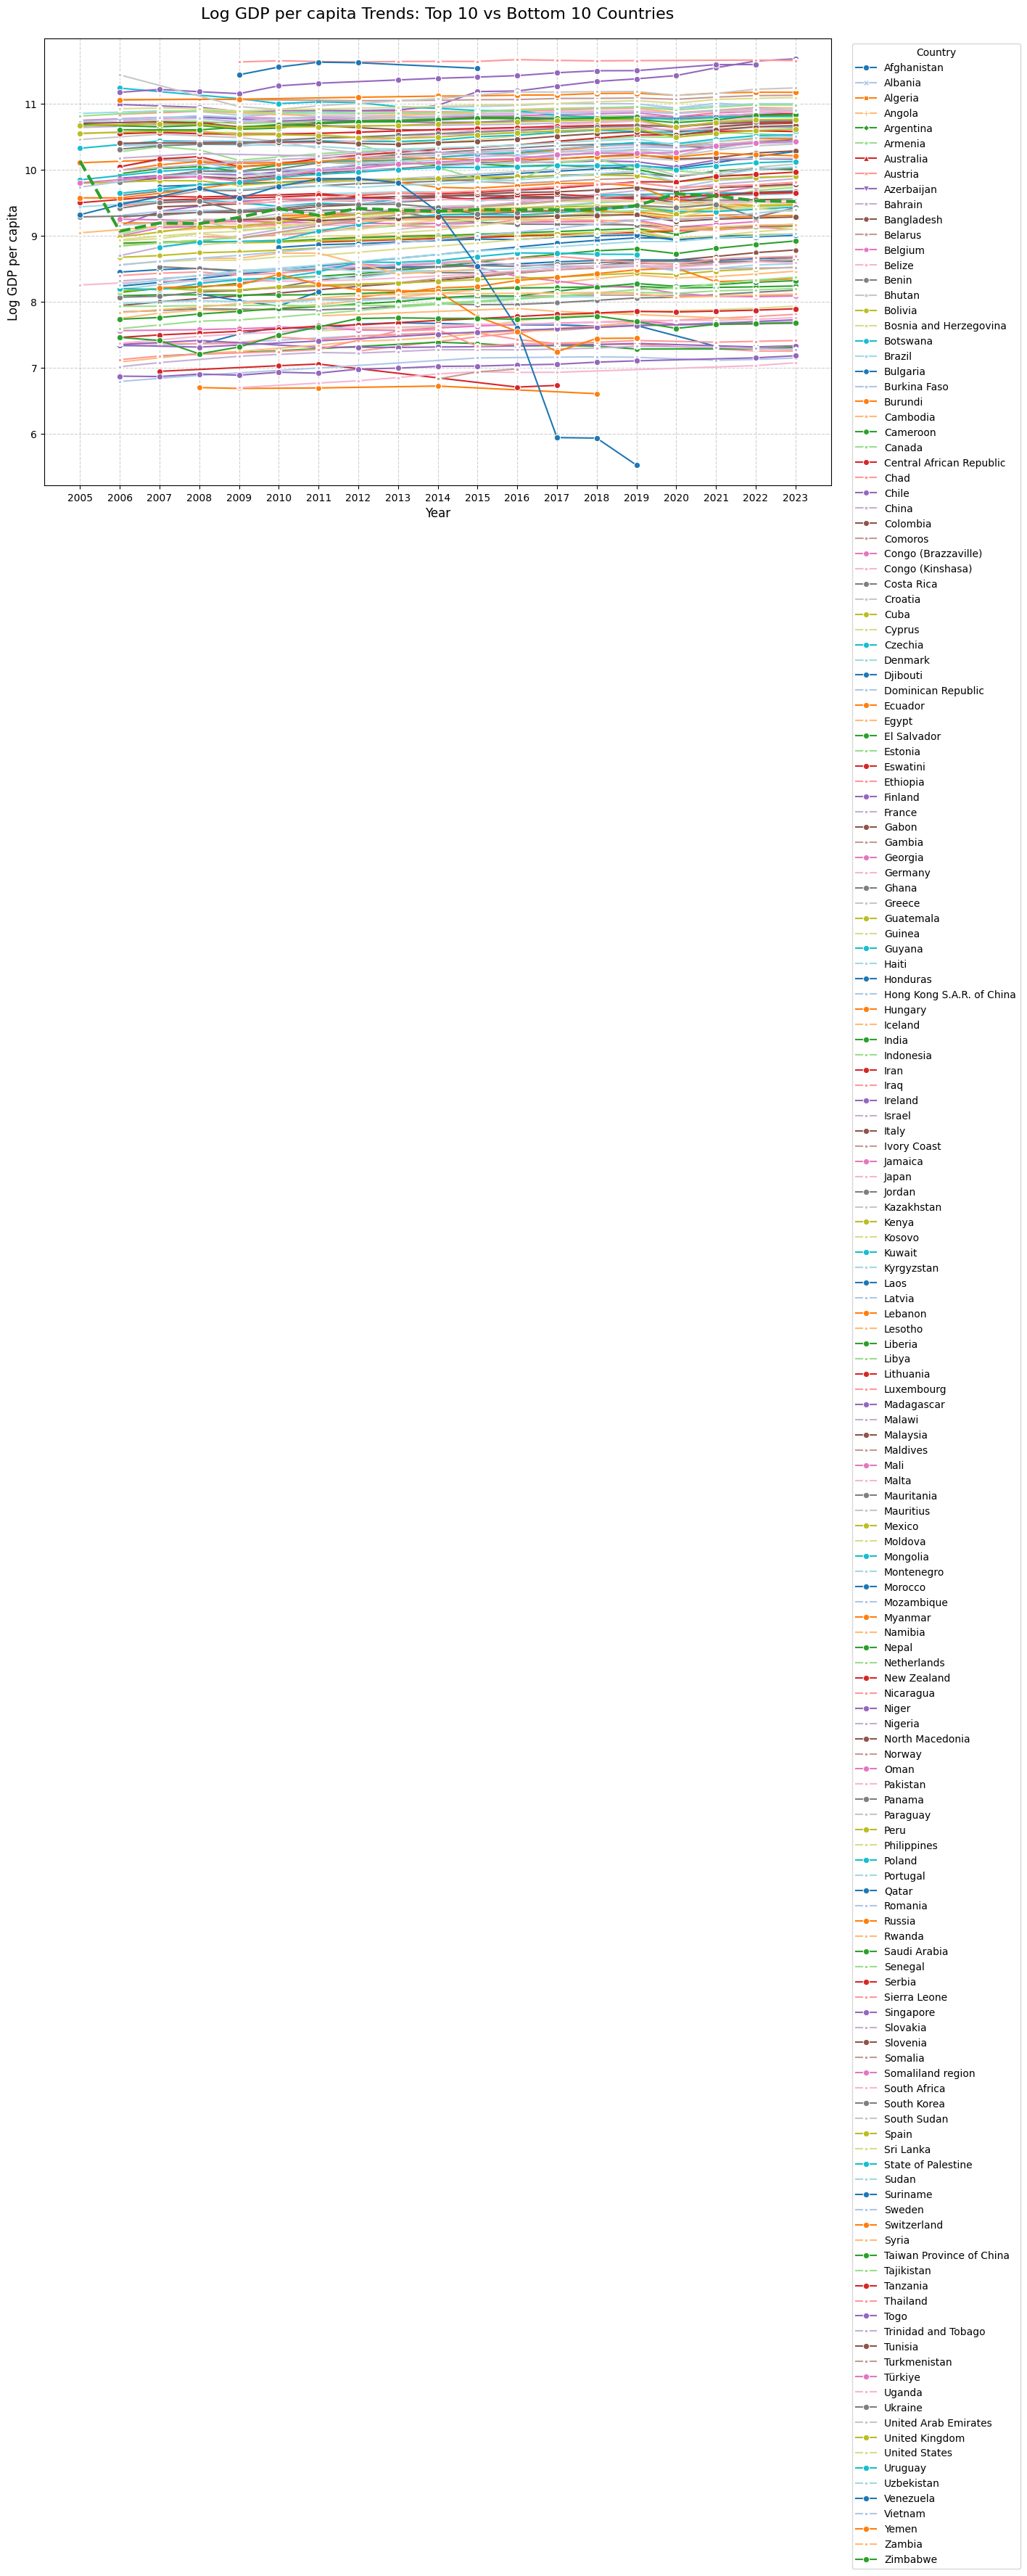

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the columns are named correctly as per your data
# Expected: 'Country name', 'year', 'Life Ladder'

# 2. Select countries to plot to avoid overcrowding
# We will pick the Top 10 and Bottom 10 countries by average Life Ladder score
avg_happiness = df.groupby('Country name')['Log GDP per capita'].mean().sort_values(ascending=False)

top_10_countries = avg_happiness.head(85).index.tolist()
bottom_10_countries = avg_happiness.tail(80).index.tolist()
selected_countries = top_10_countries + bottom_10_countries

# Filter the dataframe
plot_data = df[df['Country name'].isin(selected_countries)]

# 3. Create the Time Series Plot
plt.figure(figsize=(14, 8))

# Use seaborn for easier handling of groups (hue)
sns.lineplot(
    data=plot_data,
    x='year',
    y='Log GDP per capita',
    hue='Country name',
    style='Country name', # Adds different line styles for better distinction
    markers=True,
    dashes=False,
    palette='tab20'       # A palette with many distinct colors
)

# Customizing the plot
plt.title('Log GDP per capita Trends: Top 10 vs Bottom 10 Countries', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log GDP per capita', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df['year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()

# Add mean Life Ladder line
# Compute mean Life Ladder per year
mean_per_year = (
    plot_data
    .groupby('year')['Log GDP per capita']
    .mean()
    .reset_index()
)

# Plot mean per year line
plt.plot(
    mean_per_year['year'],
    mean_per_year['Log GDP per capita'],
    linestyle='--',
    linewidth=3,
    label='Mean Log GDP per capita per Year'
)

# 4. Show the plot
plt.show()

/tmp/ipython-input-1347588796.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


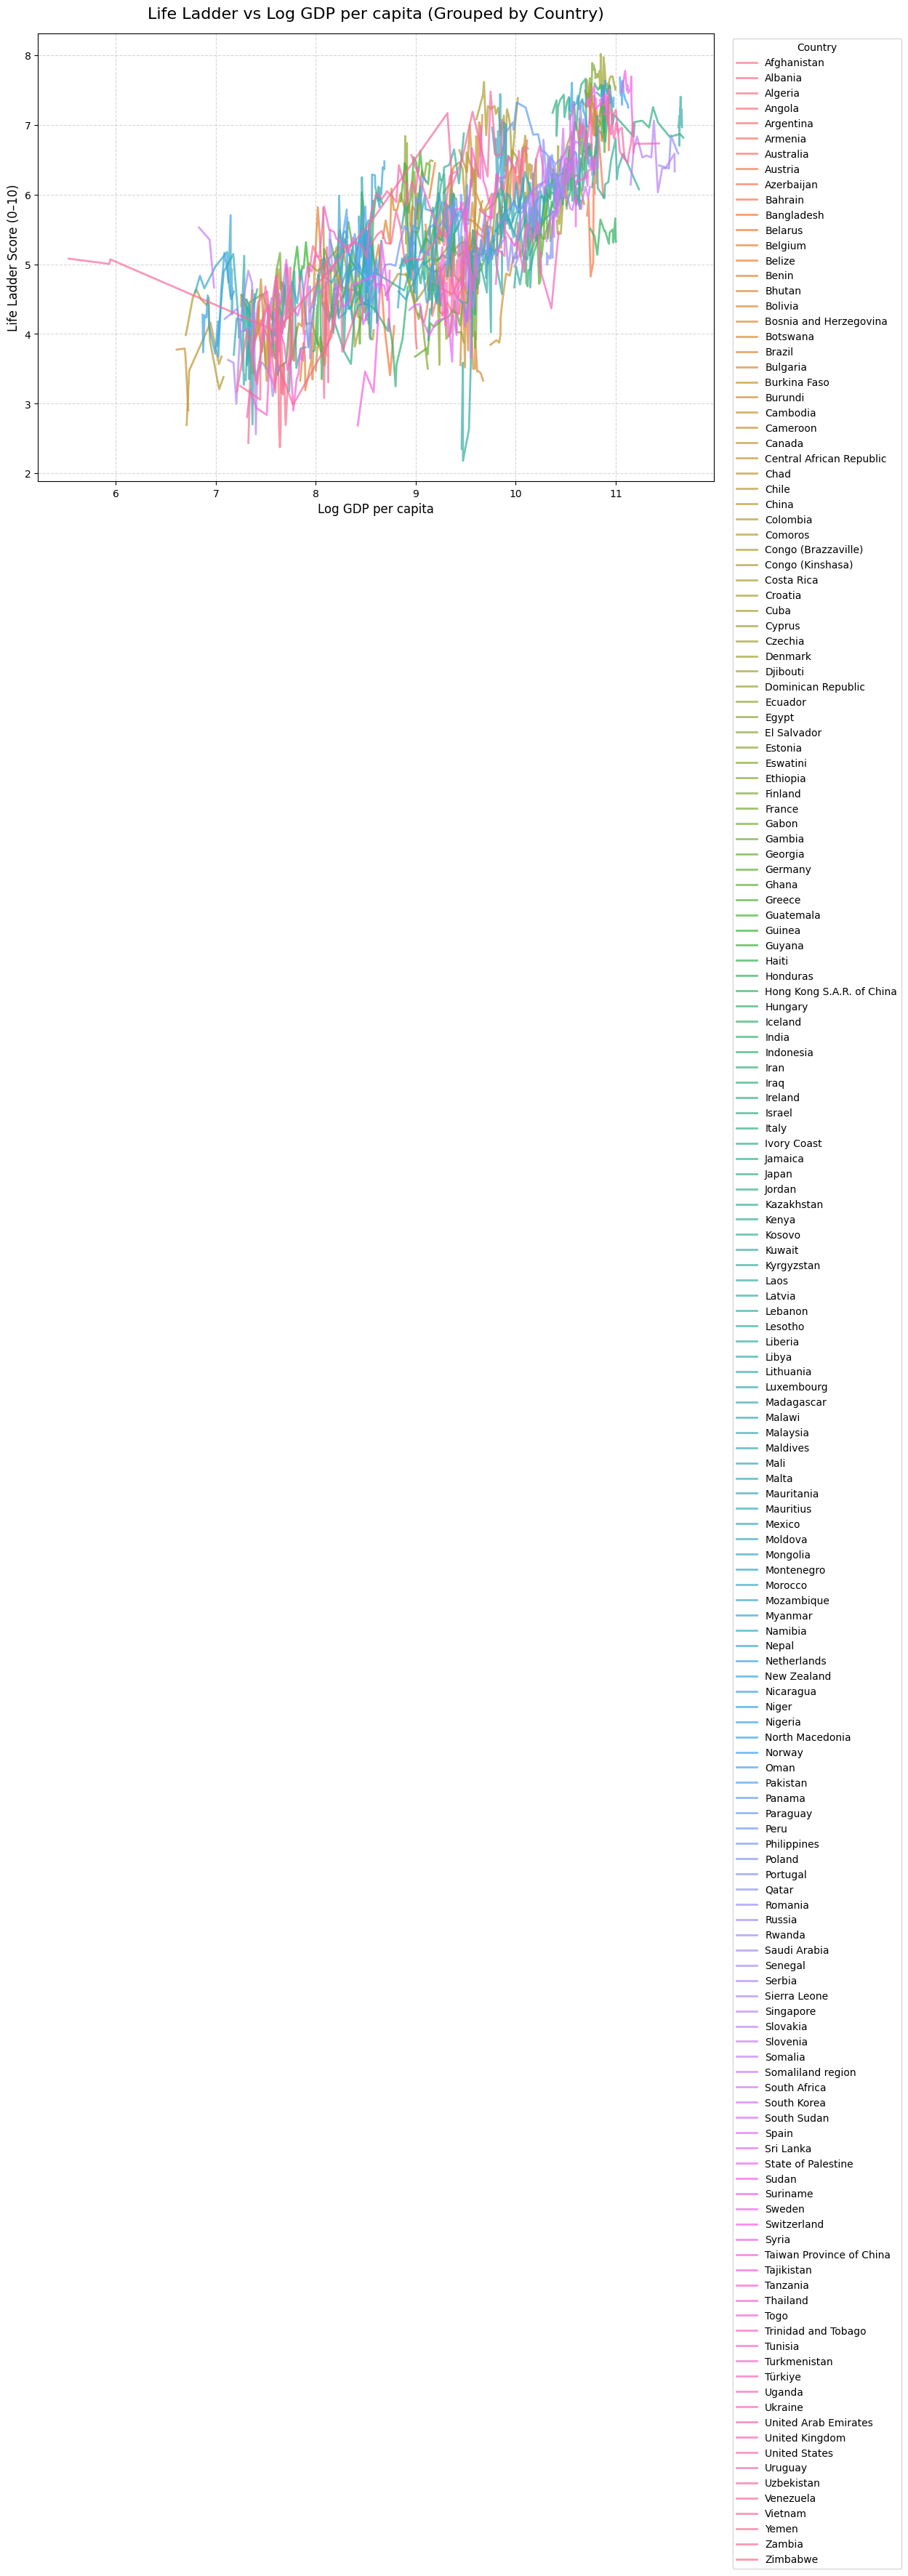

In [ ]:
plot_data = plot_data.sort_values(
    by=['Country name', 'year']
)
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=plot_data,
    x='Log GDP per capita',
    y='Life Ladder',
    hue='Country name',
    units='Country name',     # ensures one line per country
    estimator=None,           # prevents averaging across countries
    linewidth=2,
    alpha=0.7
)

plt.title(
    'Life Ladder vs Log GDP per capita (Grouped by Country)',
    fontsize=16,
    pad=15
)
plt.xlabel('Log GDP per capita', fontsize=12)
plt.ylabel('Life Ladder Score (0–10)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


In [ ]:
# Define the bins and labels
bins = [0, 5, 7, 10]
labels = ['Low', 'Medium', 'High']

# Create categorical column
df['Life Ladder Category'] = pd.cut(df['Life Ladder'], bins=bins, labels=labels, include_lowest=True)

# Check result
print(df[['Life Ladder', 'Life Ladder Category']].head())


   Life Ladder Life Ladder Category
0     3.723590                  Low
1     4.401778                  Low
2     4.758381                  Low
3     3.831719                  Low
4     3.782938                  Low


/tmp/ipython-input-573282618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Life Ladder Category', palette='Set2')


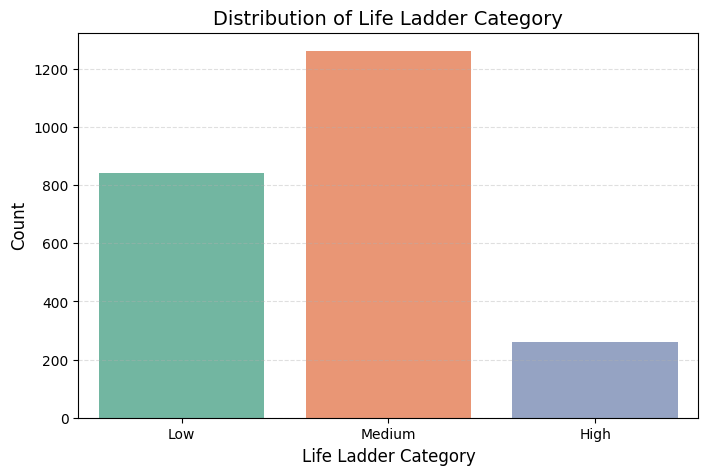

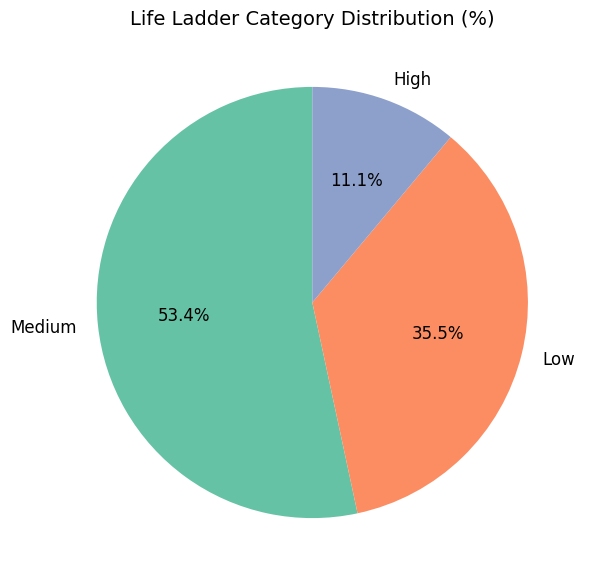

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Count distribution (barplot)
# ============================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Life Ladder Category', palette='Set2')

plt.title("Distribution of Life Ladder Category", fontsize=14)
plt.xlabel("Life Ladder Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# ============================
# 2. Pie chart (optional)
# ============================

plt.figure(figsize=(7, 7))

df['Life Ladder Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2"),
    textprops={'fontsize': 12}
)

plt.title("Life Ladder Category Distribution (%)", fontsize=14)
plt.ylabel("")   # remove y-label for cleaner look
plt.show()


In [ ]:
df[num_cols].isnull().sum()

,0
year,0
Log GDP per capita,28
Social support,13
Healthy life expectancy at birth,63
Freedom to make life choices,36
Generosity,81
Perceptions of corruption,125
Positive affect,24
Negative affect,16


In [ ]:
df.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
count,2363.000000,2363.000000,2335.000000,2350.000000,2300.000000,2327.000000,2282.000000,2238.000000,2339.000000,2347.000000
mean,2014.763860,5.483562,9.399673,0.809369,63.401828,0.750290,0.000096,0.743959,0.651878,0.273160
std,5.059436,1.125523,1.152062,0.121211,6.842644,0.139366,0.161386,0.184871,0.106249,0.087133
min,2005.000000,1.281271,5.526723,0.228217,6.720000,0.228301,-0.339547,0.035198,0.178886,0.082737
25%,2011.000000,4.646750,8.506165,0.743811,59.195001,0.660706,-0.111940,0.686784,0.571977,0.208559
50%,2015.000000,5.448725,9.502946,0.834395,65.099998,0.771122,-0.021613,0.798497,0.663420,0.262175
75%,2019.000000,6.323592,10.392974,0.903779,68.552502,0.861740,0.093569,0.867557,0.737262,0.326211
max,2023.000000,8.018934,11.675588,0.987343,74.599998,0.985178,0.699570,0.983276,0.883586,0.704590


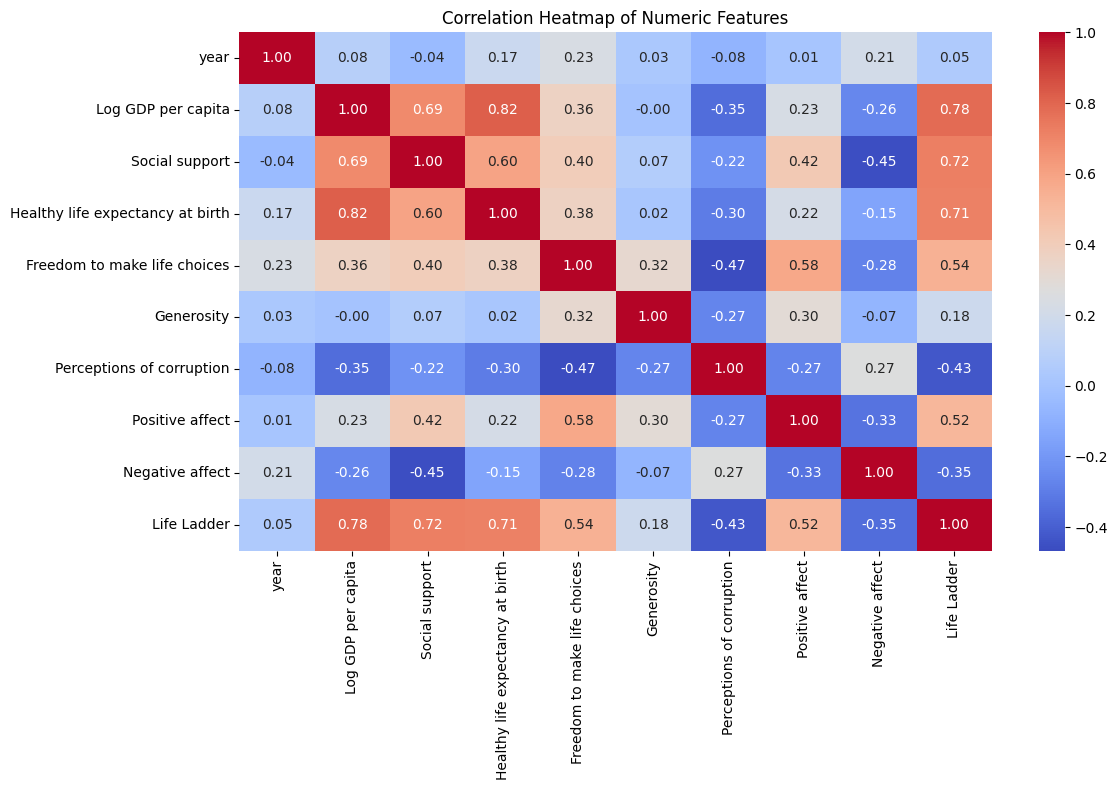

In [ ]:
corr_matrix = df[num_cols+target_col].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

# Fill Missing Value

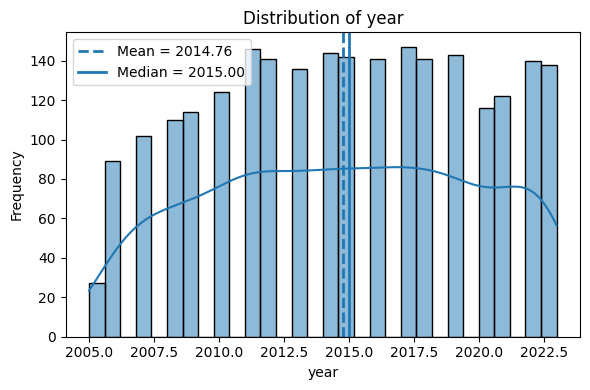

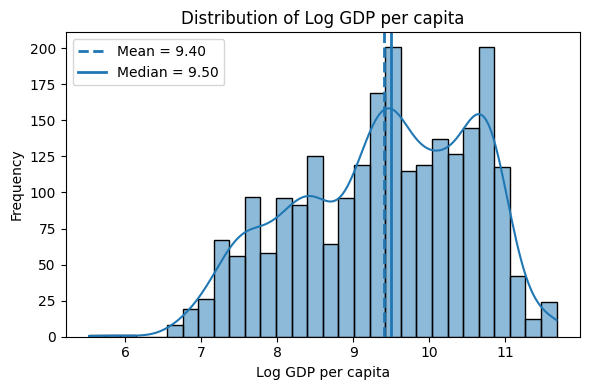

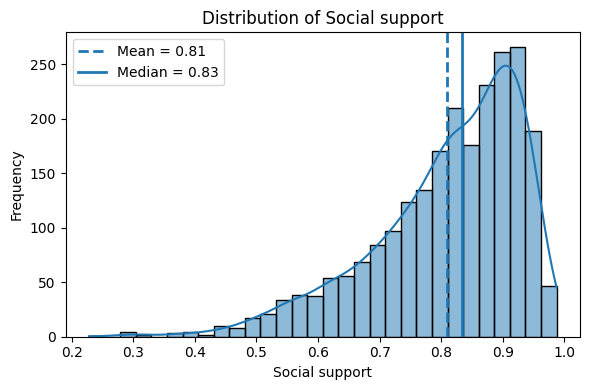

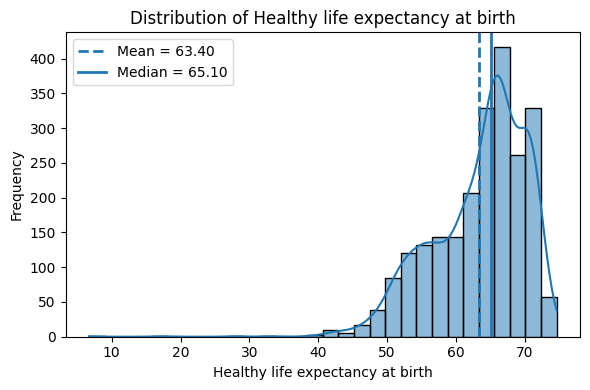

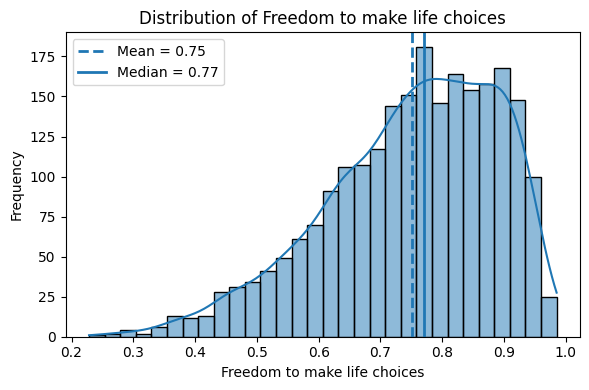

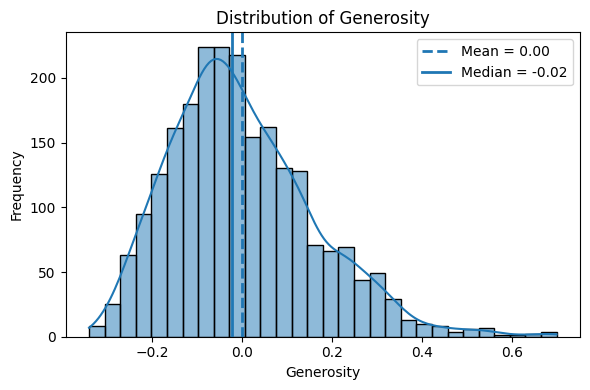

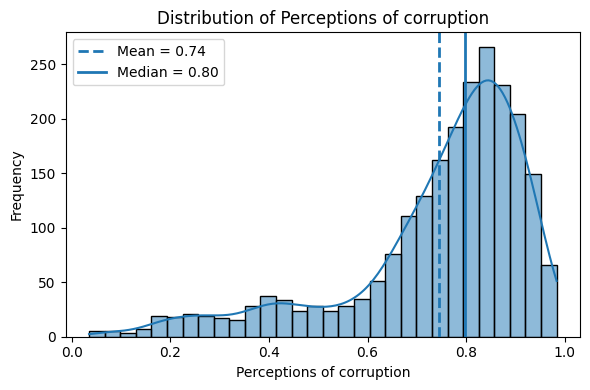

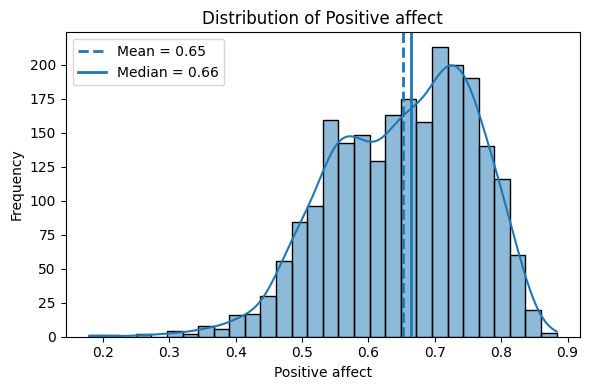

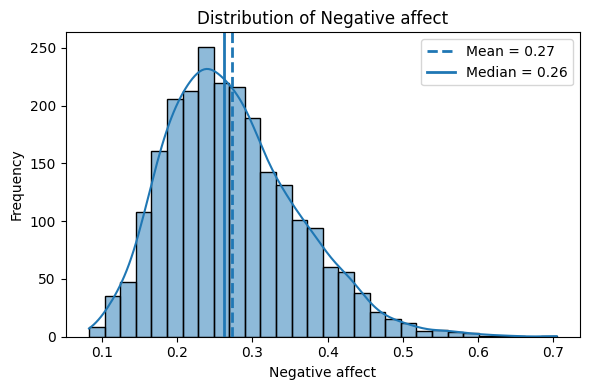

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)

    # Calculate mean and median
    mean_val = df[col].mean()
    median_val = df[col].median()

    # Plot vertical lines
    plt.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")
    plt.axvline(median_val, linestyle='-', linewidth=2, label=f"Median = {median_val:.2f}")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

Use median because the feature has outliers and a skewed distribution.

In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df[num_cols].isnull().sum()

,0
year,0
Log GDP per capita,0
Social support,0
Healthy life expectancy at birth,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0
Positive affect,0
Negative affect,0


# Handle outlier

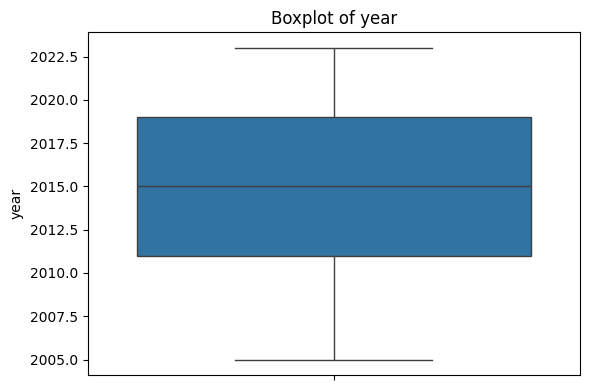

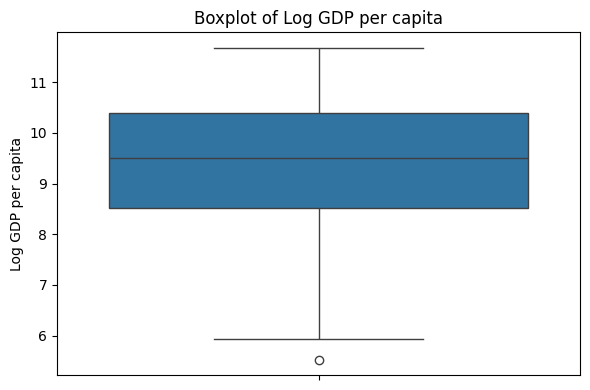

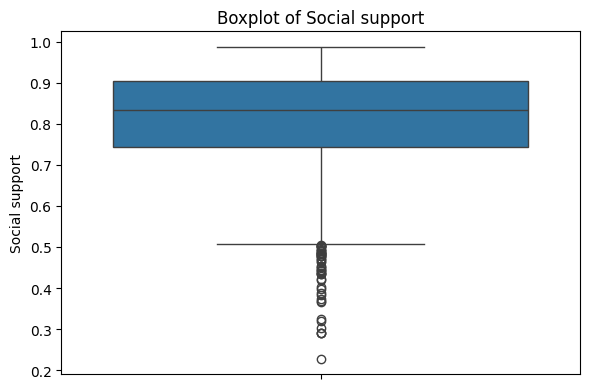

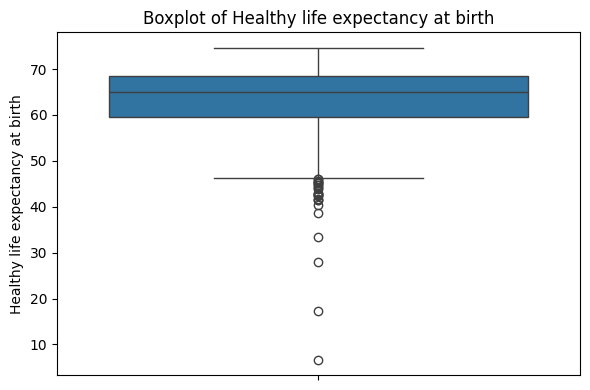

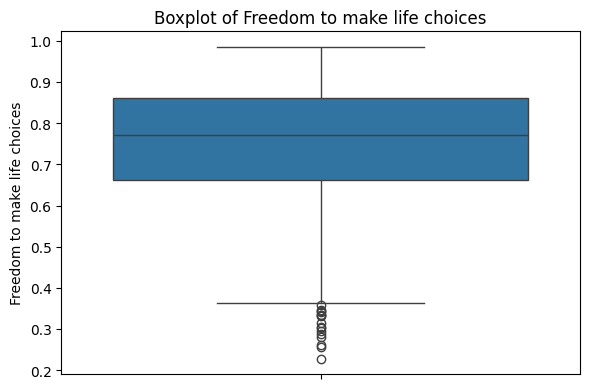

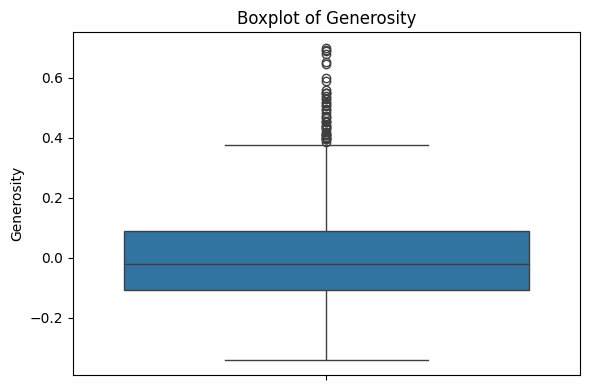

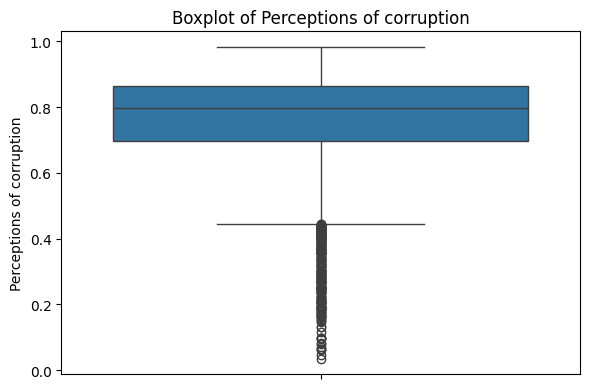

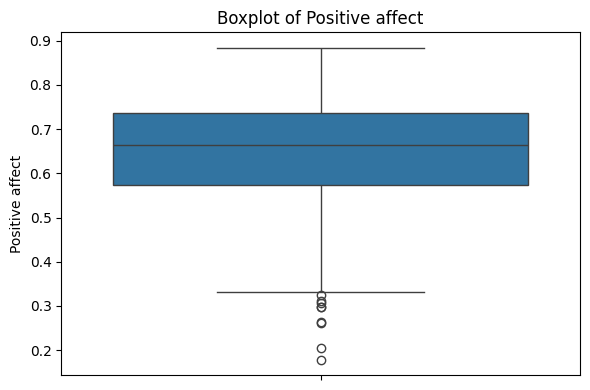

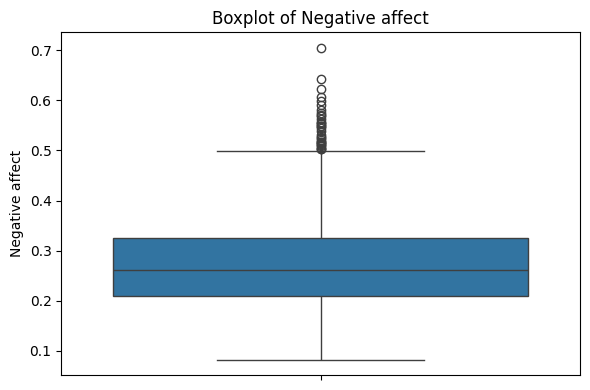

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
outlier_percentages = {}

for col in num_cols:
    if pd.api.types.is_numeric_dtype(df[col]):  # ensure numeric
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        percent = (len(outliers) / len(df)) * 100
        outlier_percentages[col] = percent

# Print results
for col, pct in outlier_percentages.items():
    print(f"{col}: {pct:.2f}% outliers")

from sklearn.preprocessing import RobustScaler

# Create scaler
scaler = RobustScaler()

# Apply scaling
df[num_cols] = scaler.fit_transform(df[num_cols])

outlier_percentages = {}

for col in num_cols:
    if pd.api.types.is_numeric_dtype(df[col]):  # ensure numeric
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        percent = (len(outliers) / len(df)) * 100
        outlier_percentages[col] = percent

# Print results
for col, pct in outlier_percentages.items():
    print(f"{col}: {pct:.2f}% outliers")

year: 0.00% outliers
Log GDP per capita: 0.04% outliers
Social support: 2.12% outliers
Healthy life expectancy at birth: 1.14% outliers
Freedom to make life choices: 0.68% outliers
Generosity: 1.86% outliers
Perceptions of corruption: 9.61% outliers
Positive affect: 0.38% outliers
Negative affect: 1.31% outliers
year: 0.00% outliers
Log GDP per capita: 0.04% outliers
Social support: 2.12% outliers
Healthy life expectancy at birth: 1.14% outliers
Freedom to make life choices: 0.68% outliers
Generosity: 1.86% outliers
Perceptions of corruption: 9.61% outliers
Positive affect: 0.38% outliers
Negative affect: 1.31% outliers


In [ ]:
from sklearn.preprocessing import RobustScaler

# Create scaler
scaler = RobustScaler()

# Apply scaling
df[num_cols] = scaler.fit_transform(df[num_cols])


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Apply scaling
df[num_cols] = scaler.fit_transform(df[num_cols])


RobustScaler does not remove outliers — it just reduces their influence.

In [ ]:
outlier_percentages = {}

for col in num_cols:
    if pd.api.types.is_numeric_dtype(df[col]):  # ensure numeric
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        percent = (len(outliers) / len(df)) * 100
        outlier_percentages[col] = percent

# Print results
for col, pct in outlier_percentages.items():
    print(f"{col}: {pct:.2f}% outliers")

year: 0.00% outliers
Log GDP per capita: 0.04% outliers
Social support: 2.12% outliers
Healthy life expectancy at birth: 1.14% outliers
Freedom to make life choices: 0.68% outliers
Generosity: 1.86% outliers
Perceptions of corruption: 9.61% outliers
Positive affect: 0.38% outliers
Negative affect: 1.31% outliers


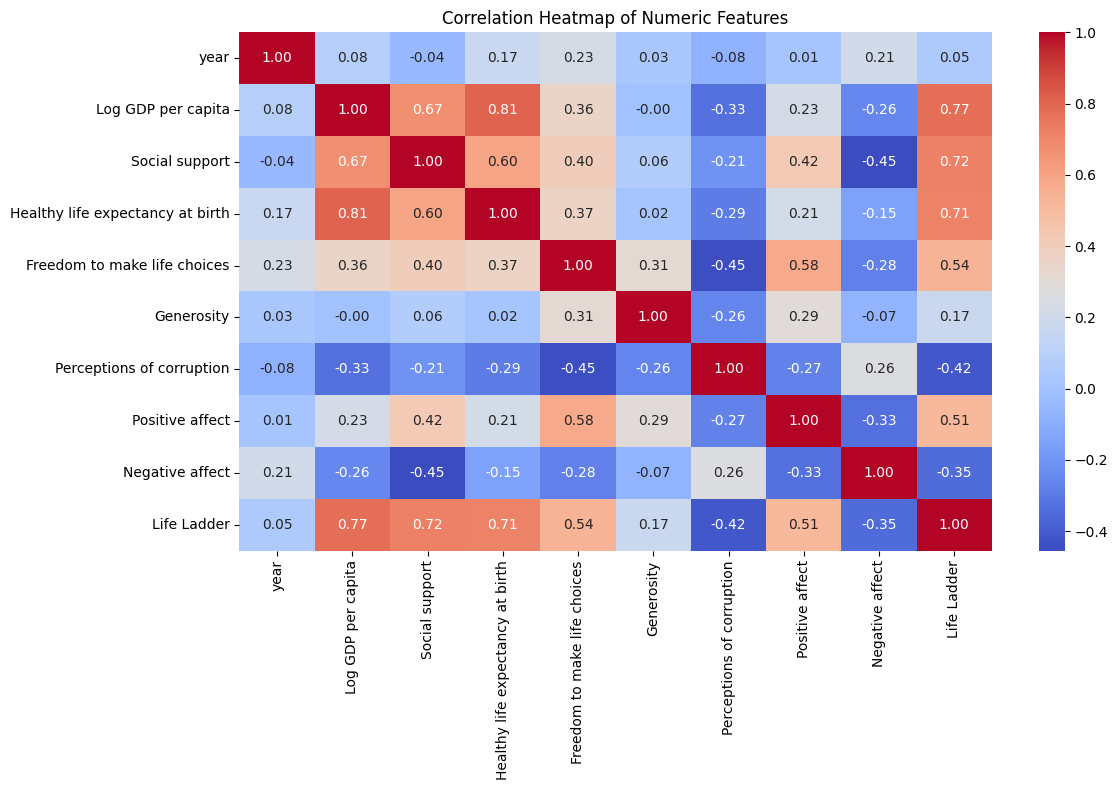

In [ ]:
corr_matrix = df[num_cols + target_col].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calculate correlation matrix
corr_matrix = df[num_cols].corr().abs()

# Only consider upper triangle to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation above threshold (e.g. 0.8)
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Columns to consider dropping due to high correlation:")
print(to_drop)


Columns to consider dropping due to high correlation:
['Healthy life expectancy at birth']


# model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = 'Life Ladder'

# Ensure no extra spaces and correct spelling
X = df[num_cols].drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

KeyError: "['Life Ladder'] not found in axis"

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

results = {}
feature_importances = {}


In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

    # Feature importance only for tree models
    if hasattr(model, "feature_importances_"):
        feature_importances[name] = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)


In [ ]:
pd.DataFrame(results).T

In [ ]:
for name, importance in feature_importances.items():
    print(f"\nFeature Importance - {name}\n")
    print(importance)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Giả sử X_train, X_test đã được RobustScaler transform từ trước
# X_train, X_test, y_train, y_test đã có sẵn

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 500],          # số cây
    "max_depth": [None, 5, 10, 20],          # độ sâu tối đa của cây
    "min_samples_split": [2, 5, 10],         # min samples để split
    "min_samples_leaf": [1, 2, 4]            # min samples ở leaf
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,                                    # 5-fold CV
    scoring="neg_mean_absolute_error",       # tối ưu MAE (càng nhỏ càng tốt)
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV MAE:", -grid_rf.best_score_)  # đổi dấu vì là negative MAE

best_rf = grid_rf.best_estimator_

# Đánh giá trên test set
y_pred_rf = best_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest (tuned) performance on test set:")
print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²  : {r2_rf:.4f}")


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_dist_xgb = {
    "n_estimators": [200, 300, 400, 500],       # số cây
    "max_depth": [3, 4, 5, 6],                  # độ sâu cây
    "learning_rate": [0.01, 0.03, 0.05, 0.1],   # tốc độ học
    "subsample": [0.7, 0.8, 1.0],               # tỉ lệ sample cho mỗi cây
    "colsample_bytree": [0.7, 0.8, 1.0],        # tỉ lệ feature cho mỗi cây
    "reg_lambda": [1, 5, 10, 20]                # L2 regularization
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,                                  # số cấu hình thử; tăng nếu muốn kỹ hơn
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

print("Best XGB params:", random_xgb.best_params_)
print("Best XGB CV MAE:", -random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_

# Đánh giá trên test set
y_pred_xgb = best_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost (tuned) performance on test set:")
print(f"MAE : {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²  : {r2_xgb:.4f}")


In [ ]:
from sklearn.preprocessing import LabelEncoder

target_col_class = 'Life Ladder Category'

# Encode the categorical target to numerical labels
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df[target_col_class])


In [ ]:
X = df[num_cols]
print(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Define MLP model
# hidden_layer_sizes=(64, 32): 2 hidden layers with 64 and 32 neurons
# activation='relu': common choice for deep learning
# solver='adam': adaptive optimizer
# max_iter=500: increase to allow convergence
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=5000,
    random_state=42
)


In [ ]:
# Train / Huấn luyện MLP
mlp.fit(X_train, y_train)

# Predict / Dự đoán
y_pred_mlp = mlp.predict(X_test)

# Metrics: Accuracy & F1-score
acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

print("MLP Classifier Performance:")
print(f"Accuracy: {acc_mlp:.4f}")
print(f"F1-score: {f1_mlp:.4f}")

print("\nClassification Report (MLP):")
import numpy as np

all_labels = np.arange(len(label_encoder.classes_))  # [0,1,2,3,4]
print(classification_report(
    y_test,
    y_pred_mlp,
    labels=all_labels,
    target_names=label_encoder.classes_
))



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Result

=== Overall Comparison ===
           Model  Accuracy_CV  Weighted_F1_CV
0  Random Forest       0.8722          0.8719
1      KNN (k=5)       0.8764          0.8764 

=== Per-class F1-score Comparison ===
    Class   RF_F1  KNN_F1
0     Low  0.8680  0.8822
1  Medium  0.8818  0.8834
2    High  0.8367  0.8244


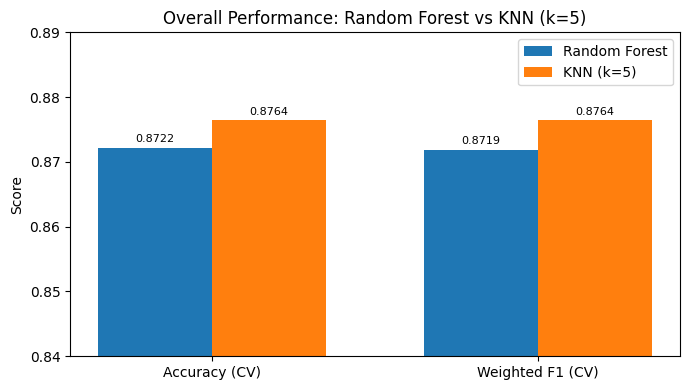

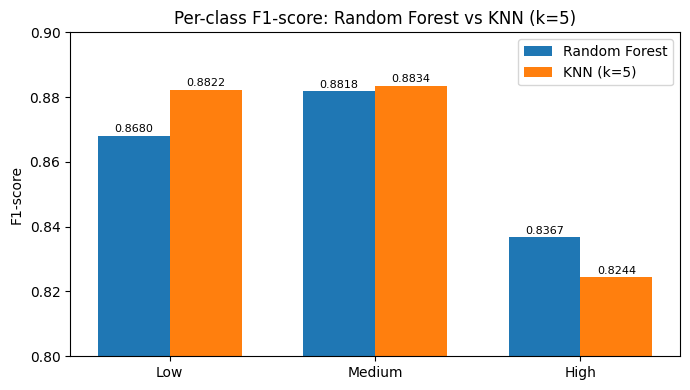

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 1. Create data tables
# ============================

# Overall metrics
data_overall = {
    "Model": ["Random Forest", "KNN (k=5)"],
    "Accuracy_CV": [0.8722, 0.8764],
    "Weighted_F1_CV": [0.8719, 0.8764],
}
df_overall = pd.DataFrame(data_overall)

# Per-class F1
data_per_class = {
    "Class": ["Low", "Medium", "High"],
    "RF_F1": [0.8680, 0.8818, 0.8367],
    "KNN_F1": [0.8822, 0.8834, 0.8244],
}
df_per_class = pd.DataFrame(data_per_class)

print("=== Overall Comparison ===")
print(df_overall.round(4), "\n")

print("=== Per-class F1-score Comparison ===")
print(df_per_class.round(4))


# ============================
# 2. Plot: Overall metrics comparison
# ============================

plt.figure(figsize=(7, 4))

metrics = ["Accuracy_CV", "Weighted_F1_CV"]
x = range(len(metrics))  # [0, 1]
width = 0.35

# Bars for Random Forest and KNN
plt.bar(
    [i - width/2 for i in x],
    df_overall.loc[0, metrics],
    width=width,
    label="Random Forest"
)
plt.bar(
    [i + width/2 for i in x],
    df_overall.loc[1, metrics],
    width=width,
    label="KNN (k=5)"
)

# X-axis labels
plt.xticks(x, ["Accuracy (CV)", "Weighted F1 (CV)"])
plt.ylabel("Score")
plt.ylim(0.84, 0.89)
plt.title("Overall Performance: Random Forest vs KNN (k=5)")
plt.legend()

# Add value labels on top of bars
for i in x:
    # RF
    val_rf = df_overall.loc[0, metrics[i]]
    plt.text(i - width/2, val_rf + 0.0005, f"{val_rf:.4f}", ha="center", va="bottom", fontsize=8)
    # KNN
    val_knn = df_overall.loc[1, metrics[i]]
    plt.text(i + width/2, val_knn + 0.0005, f"{val_knn:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


# ============================
# 3. Plot: Per-class F1 comparison
# ============================

plt.figure(figsize=(7, 4))

classes = df_per_class["Class"]
x = range(len(classes))  # [0, 1, 2]
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    df_per_class["RF_F1"],
    width=width,
    label="Random Forest"
)
plt.bar(
    [i + width/2 for i in x],
    df_per_class["KNN_F1"],
    width=width,
    label="KNN (k=5)"
)

plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.ylim(0.80, 0.90)
plt.title("Per-class F1-score: Random Forest vs KNN (k=5)")
plt.legend()

# Add value labels
for i in x:
    rf_val = df_per_class.loc[i, "RF_F1"]
    knn_val = df_per_class.loc[i, "KNN_F1"]
    plt.text(i - width/2, rf_val + 0.0005, f"{rf_val:.4f}", ha="center", va="bottom", fontsize=8)
    plt.text(i + width/2, knn_val + 0.0005, f"{knn_val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
